# 02 · Análisis exploratorio

**Propósito.** Entender cómo se comportan los precios del dataset limpio antes de construir el modelo de
precio esperado (notebook 03), y reunir evidencia preliminar sobre las hipótesis que no dependen del modelo.

**Hipótesis de trabajo** (la redacción final está en el README):

| | Hipótesis | Dónde se evalúa |
|---|---|---|
| H1 | Dentro de una sub-zona hay avisos publicados claramente por debajo del precio esperado para sus características, más allá del margen normal de negociación (~5%). | Notebook 03 |
| H2 | Un barrio no es homogéneo: comparar dentro de la sub-zona da una referencia de precio más precisa que el barrio completo. | Sección 4 |
| H3 | Parte de la diferencia de precio dentro de un barrio se explica por la ubicación: cercanía al subte y a los polos de centralidad. | Sección 6 |

**Medida principal:** precio por m² en USD (`precio_m2_usd`). Permite comparar departamentos de distinto tamaño.
Cuando se compara dentro de un grupo se usa el **precio relativo**: cuánto más caro o más barato es un aviso
respecto del promedio de su grupo, en escala logarítmica (0,10 ≈ 10% más caro).

## 1. Configuración e ingesta

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import eda
from src.eda import AZUL, AZUL_OSCURO, GRIS, ROJO

In [3]:
PARAMS = {
    "entrada": RAIZ / "data" / "processed" / "propiedades_limpias.tsv",
    "minimo_grupo": 10,   # avisos mínimos para usar la mediana de un grupo como referencia
    "k_folds": 5,         # partes para medir el error de referencia fuera de muestra
}

In [4]:
df = pd.read_csv(PARAMS["entrada"], sep="\t", low_memory=False)
geo = df[df["subzona"].notna()].copy()   # avisos con coordenadas y sub-zona
print(f"Avisos: {len(df):,} | con sub-zona: {len(geo):,} ({100 * len(geo) / len(df):.1f}%)")
print(f"Barrios: {df['barrio'].nunique()} | sub-zonas: {geo['subzona'].nunique()}")

Avisos: 27,579 | con sub-zona: 22,633 (82.1%)
Barrios: 47 | sub-zonas: 198


## 2. Panorama general

**Pregunta:** ¿cómo se distribuyen el precio, la superficie y el precio por m²?

In [5]:
resumen = eda.resumen_numerico(df, ["precio_usd", "m2_final", "precio_m2_usd", "antiguedad", "expensas_usd"])
resumen.round(1)

,n,media,mediana,desvio,asimetria,p05,p25,p75,p95
precio_usd,27579.0,205283.4,130000.0,308244.2,12.8,55000.0,85000.0,215000.0,564100.0
m2_final,27579.0,72.3,57.0,54.0,3.3,28.0,40.0,84.0,174.0
precio_m2_usd,27579.0,2629.8,2392.9,1290.6,4.1,1269.2,1862.7,3055.6,4744.5
antiguedad,26808.0,35.5,40.0,23.1,0.2,1.0,13.0,50.0,70.0
expensas_usd,23132.0,189.5,131.7,212.2,5.4,36.2,85.0,210.8,546.8


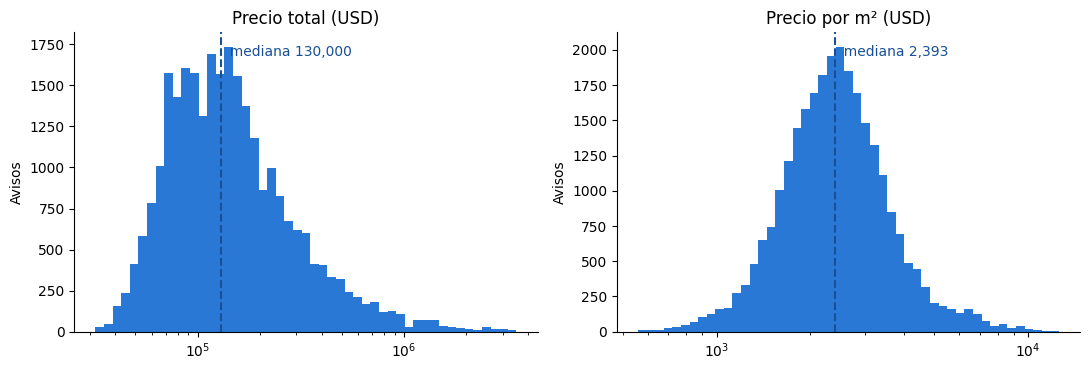

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, titulo in [
    (axes[0], "precio_usd", "Precio total (USD)"),
    (axes[1], "precio_m2_usd", "Precio por m² (USD)"),
]:
    valores = df[col]
    bins = np.logspace(np.log10(valores.quantile(0.001)), np.log10(valores.quantile(0.999)), 50)
    ax.hist(valores, bins=bins, color=AZUL)
    ax.axvline(valores.median(), color=AZUL_OSCURO, lw=1.5, ls="--")
    ax.text(valores.median(), ax.get_ylim()[1] * 0.92, f"  mediana {valores.median():,.0f}", color=AZUL_OSCURO)
    ax.set_xscale("log")
    ax.set_title(titulo)
    ax.set_ylabel("Avisos")
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [7]:
df["ambientes"].value_counts().sort_index().head(8).to_frame("avisos")

,avisos
ambientes,
1.0,4144
2.0,7421
3.0,8445
4.0,5301
5.0,1291
6.0,376
7.0,153
8.0,61


**Resultado.** El precio total tiene una asimetría fuerte a la derecha: la media (USD 205.000) está muy
por encima de la mediana (USD 130.000), empujada por el segmento de lujo. En escala logarítmica la
distribución se vuelve aproximadamente simétrica. El precio por m² es menos asimétrico, con mediana de
USD 2.393. La oferta se concentra en 2 y 3 ambientes.

> **Interpretación.** Conviene describir los precios con la **mediana**: la distribución tiene una asimetría fuerte a la derecha (asimetría de 12,8 en el precio total), y unos pocos avisos muy caros arrastran la media hacia arriba (USD 205.000 contra una mediana de USD 130.000). La mediana no se ve afectada por esos extremos, así que representa mejor un departamento típico.
>
> El análisis trabaja en escala logarítmica por dos razones. Primero, la distribución se vuelve aproximadamente simétrica y los extremos dejan de dominar los gráficos. Segundo, y más importante para el proyecto, en logaritmo las diferencias se leen como porcentajes: una diferencia de USD 300/m² es casi un 30% en Villa Lugano y apenas un 5% en Puerto Madero, mientras que "10% más caro" significa lo mismo en cualquier barrio. Por eso el precio relativo y el modelo de precio esperado se calculan en escala logarítmica.

## 3. Precio por m² según barrio

**Pregunta:** ¿cuánto varía el precio entre barrios, y cuánto dentro de cada uno?

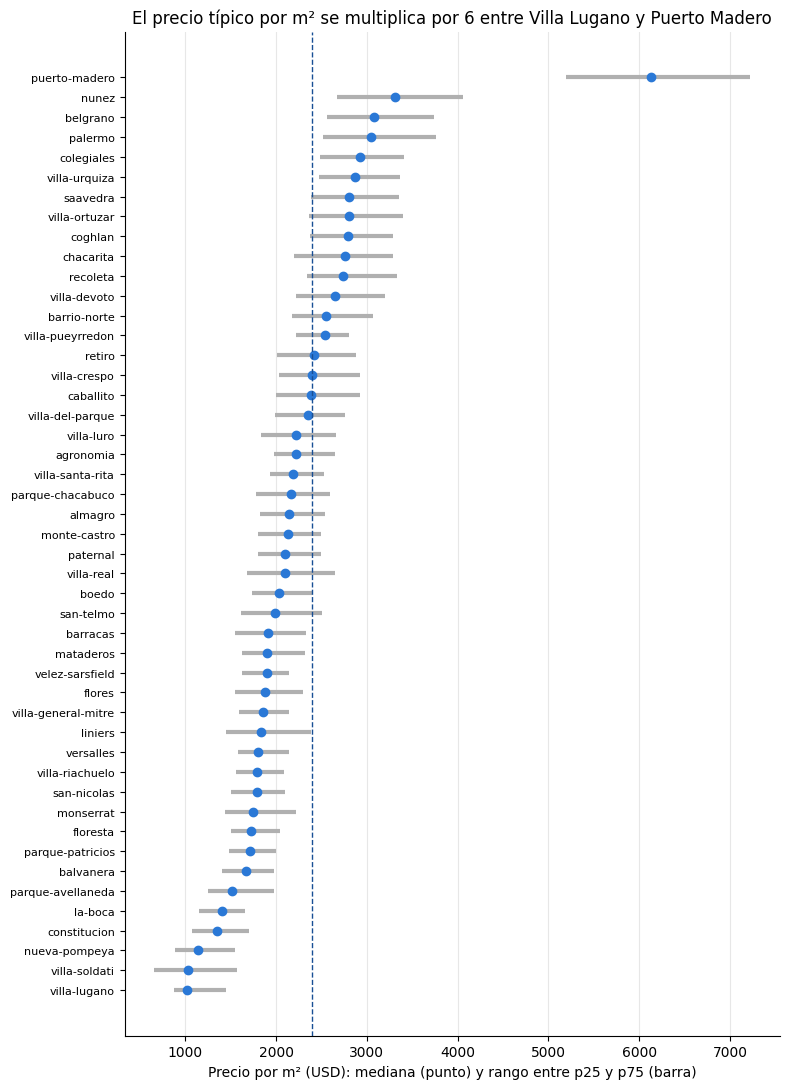

In [8]:
por_barrio = df.groupby("barrio")["precio_m2_usd"].agg(
    avisos="size",
    p25=lambda s: s.quantile(0.25),
    mediana="median",
    p75=lambda s: s.quantile(0.75),
).sort_values("mediana")
por_barrio["rango_iqr_pct"] = (100 * (por_barrio["p75"] - por_barrio["p25"]) / por_barrio["mediana"]).round(0)

fig, ax = plt.subplots(figsize=(8, 11))
y = np.arange(len(por_barrio))
ax.hlines(y, por_barrio["p25"], por_barrio["p75"], color=GRIS, lw=3)
ax.plot(por_barrio["mediana"], y, "o", color=AZUL, ms=6)
ax.set_yticks(y)
ax.set_yticklabels(por_barrio.index, fontsize=8)
ax.set_xlabel("Precio por m² (USD): mediana (punto) y rango entre p25 y p75 (barra)")
ax.set_title("El precio típico por m² se multiplica por 6 entre Villa Lugano y Puerto Madero")
ax.axvline(df["precio_m2_usd"].median(), color=AZUL_OSCURO, ls="--", lw=1)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
por_barrio[["avisos", "mediana", "rango_iqr_pct"]].round(0).sort_values("rango_iqr_pct", ascending=False).head(8)

,avisos,mediana,rango_iqr_pct
barrio,,,
villa-soldati,41,1033.0,88.0
nueva-pompeya,49,1136.0,58.0
villa-lugano,422,1016.0,57.0
liniers,368,1835.0,51.0
parque-avellaneda,102,1515.0,48.0
constitucion,283,1344.0,47.0
villa-real,19,2092.0,47.0
san-telmo,610,1986.0,45.0


**Resultado.** La mediana va de unos USD 1.000/m² (Villa Lugano, Villa Soldati) a más de USD 6.000/m²
(Puerto Madero). La línea punteada es la mediana de la ciudad. Dentro de cada barrio la dispersión también
es grande: en varios barrios el rango entre el percentil 25 y el 75 supera el 50% de la mediana.

> **Interpretación.** Con una dispersión tan grande, la mediana del barrio es una vara poco precisa: un aviso puede estar bastante por debajo de ella y seguir dentro del rango habitual del barrio (entre el percentil 25 y el 75), sin que eso indique nada raro.
>
> Además, esa dispersión no es azar: dentro de un mismo barrio conviven departamentos muy distintos, más nuevos o más antiguos, en distintas zonas del barrio, con o sin amenities. Un aviso 20% por debajo de la mediana de Palermo puede ser simplemente un departamento de 60 años, no una oportunidad. Para decidir si un aviso está barato hay que compararlo con departamentos parecidos: primero achicando la zona de comparación (la sub-zona, sección 4) y después teniendo en cuenta sus características (el precio esperado del notebook 03). Puerto Madero es un caso aparte: su mediana duplica la del segundo barrio más caro, y funciona como un mercado propio.

## 4. H2: ¿la sub-zona da una referencia más precisa que el barrio?

**Pregunta:** si para cada aviso se usa como precio de referencia la mediana de su grupo, ¿cuánto se equivoca
esa referencia con el barrio y cuánto con la sub-zona?

**Método.** Para que la comparación sea justa, la mediana de referencia de cada aviso se calcula **sin ese
aviso** (validación cruzada en 5 partes): así la división con más grupos no gana solo por tener grupos
más chicos. Se usa el error porcentual absoluto entre el precio del aviso y su referencia.

In [10]:
error_barrio = eda.error_vara_fuera_de_muestra(geo["precio_m2_usd"], geo["barrio"], k=PARAMS["k_folds"], minimo_grupo=PARAMS["minimo_grupo"])
error_subzona = eda.error_vara_fuera_de_muestra(geo["precio_m2_usd"], geo["subzona"], k=PARAMS["k_folds"], minimo_grupo=PARAMS["minimo_grupo"])
comparables = error_barrio.notna() & error_subzona.notna()

print(f"Avisos comparables: {comparables.sum():,}")
print(f"Error mediano usando el barrio:   {100 * error_barrio[comparables].median():.1f}%")
print(f"Error mediano usando la sub-zona: {100 * error_subzona[comparables].median():.1f}%")

Avisos comparables: 22,540
Error mediano usando el barrio:   17.7%
Error mediano usando la sub-zona: 17.2%


In [11]:
mejora = pd.DataFrame({
    "error_barrio": error_barrio[comparables],
    "error_subzona": error_subzona[comparables],
    "barrio": geo.loc[comparables, "barrio"],
}).groupby("barrio").median()
mejora = mejora[geo.groupby("barrio")["subzona"].nunique().reindex(mejora.index) > 1]   # solo barrios con más de una sub-zona
mejora["mejora_pp"] = 100 * (mejora["error_barrio"] - mejora["error_subzona"])
mejora = mejora.sort_values("mejora_pp")
print(f"Barrios con más de una sub-zona: {len(mejora)} | la sub-zona mejora en {(mejora['mejora_pp'] > 0).sum()}")

Barrios con más de una sub-zona: 41 | la sub-zona mejora en 28


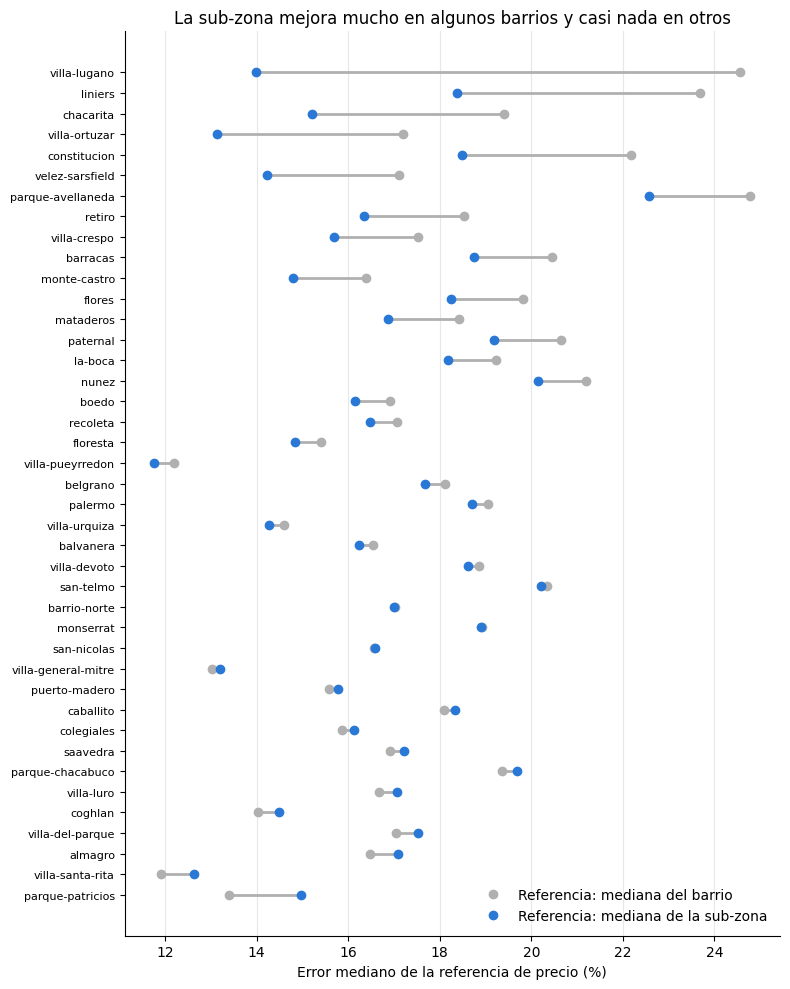

In [12]:
fig, ax = plt.subplots(figsize=(8, 10))
y = np.arange(len(mejora))
ax.hlines(y, 100 * mejora["error_subzona"], 100 * mejora["error_barrio"], color=GRIS, lw=2)
ax.plot(100 * mejora["error_barrio"], y, "o", color=GRIS, ms=6, label="Referencia: mediana del barrio")
ax.plot(100 * mejora["error_subzona"], y, "o", color=AZUL, ms=6, label="Referencia: mediana de la sub-zona")
ax.set_yticks(y)
ax.set_yticklabels(mejora.index, fontsize=8)
ax.set_xlabel("Error mediano de la referencia de precio (%)")
ax.set_title("La sub-zona mejora mucho en algunos barrios y casi nada en otros")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
mejora.round(3).tail(5)

,error_barrio,error_subzona,mejora_pp
barrio,,,
constitucion,0.222,0.185,3.692
villa-ortuzar,0.172,0.131,4.057
chacarita,0.194,0.152,4.197
liniers,0.237,0.184,5.304
villa-lugano,0.246,0.140,10.564


**Resultado.** En toda la ciudad, la sub-zona reduce el error de la referencia apenas de 17,7% a 17,2%.
Pero el promedio esconde situaciones muy distintas: en Villa Lugano el error baja de 25% a 14%, y también
mejora mucho en Liniers, Chacarita, Villa Ortúzar y Constitución. En otros barrios la sub-zona empeora
un poco la referencia, porque sus grupos tienen menos avisos y la mediana se vuelve más inestable.

> **Interpretación.** La evidencia apoya H2 parcialmente. En el total de la ciudad la mejora es chica (de 17,7% a 17,2% de error), insuficiente para afirmar que la sub-zona es siempre una mejor referencia. Pero el promedio esconde dos situaciones distintas: en barrios que mezclan zonas muy diferentes por dentro, como Villa Lugano, Liniers o Constitución, la sub-zona separa partes del barrio con precios muy distintos y el error baja mucho (en Villa Lugano, de 25% a 14%). En barrios más homogéneos, dividir no aporta información y además deja grupos más chicos, con medianas menos estables, por lo que el error se mantiene o empeora un poco.
>
> La recomendación para el fondo es usar la sub-zona como referencia solo en los barrios donde reduce el error fuera de muestra, y el barrio completo en los demás. Es un criterio medible, que refina la decisión de la PreEntrega 1 (sub-zona con un mínimo de avisos y el barrio como respaldo), y se aplica en el modelo del notebook 03.

## 5. Distribución espacial

**Pregunta:** ¿dónde están los departamentos caros y los baratos?

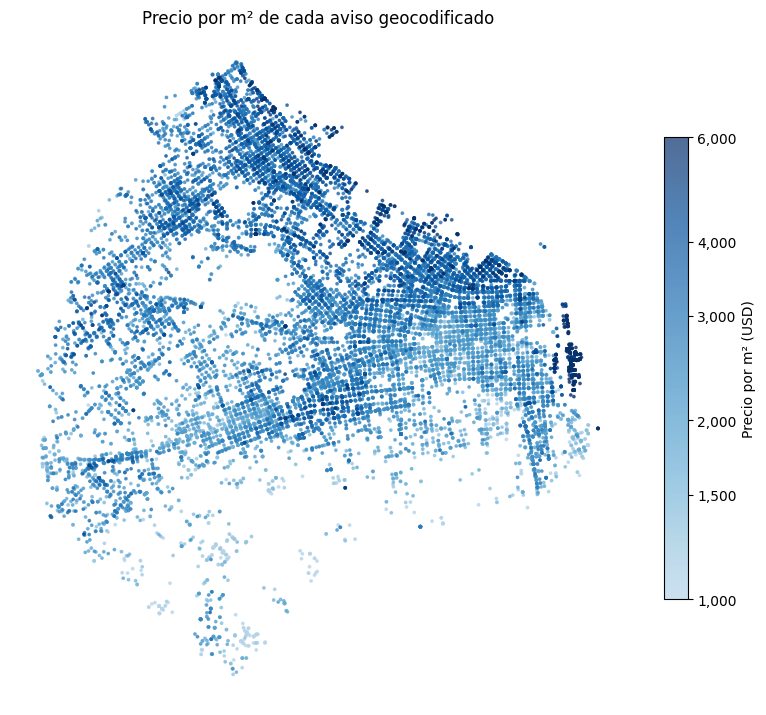

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
orden = geo.sort_values("precio_m2_usd")
from matplotlib.colors import LinearSegmentedColormap
azules = LinearSegmentedColormap.from_list("azules", plt.cm.Blues(np.linspace(0.3, 1, 256)))   # sin el tramo casi blanco
puntos = ax.scatter(orden["lon"], orden["lat"], c=np.log10(orden["precio_m2_usd"]), cmap=azules,
                    s=3, alpha=0.7, vmin=np.log10(1000), vmax=np.log10(6000))
barra = fig.colorbar(puntos, ax=ax, shrink=0.6)
ticks = [1000, 1500, 2000, 3000, 4000, 6000]
barra.set_ticks(np.log10(ticks))
barra.set_ticklabels([f"{t:,}" for t in ticks])
barra.set_label("Precio por m² (USD)")
ax.set_title("Precio por m² de cada aviso geocodificado")
ax.set_aspect(1 / np.cos(np.radians(-34.6)))
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)
plt.tight_layout()
plt.show()

**Resultado.** Los precios altos se concentran en el corredor norte, sobre el río (Puerto Madero, Retiro,
Recoleta, Palermo, Belgrano, Núñez), y bajan hacia el sur y el oeste. Es el mismo patrón que se encontró en
la PreEntrega 1: el valor no gira alrededor del centro geográfico sino a lo largo del corredor norte.

## 6. H3: ¿la ubicación explica diferencias de precio dentro de un barrio?

**Pregunta:** dentro de un mismo barrio, ¿los departamentos más cerca del subte o de los polos de
centralidad son más caros?

**Método.** Para no mezclar el efecto de la ubicación con la diferencia entre barrios, se compara el precio
relativo **al promedio del barrio** con la distancia. Se usa la correlación de Spearman, que no supone una
relación lineal.

In [15]:
log_precio = np.log(geo["precio_m2_usd"])
filas = []
for variable in ["dist_transporte_m", "dist_centralidad_m"]:
    rho_global, _, n = eda.correlacion_intra_grupo(geo[variable], log_precio, pd.Series(0, index=geo.index))
    rho_intra, p_intra, _ = eda.correlacion_intra_grupo(geo[variable], log_precio, geo["barrio"])
    filas.append({"variable": variable, "spearman_toda_la_ciudad": rho_global,
                  "spearman_dentro_del_barrio": rho_intra, "p_valor_dentro": p_intra, "n": n})
pd.DataFrame(filas).set_index("variable").round(4)

,spearman_toda_la_ciudad,spearman_dentro_del_barrio,p_valor_dentro,n
variable,,,,
dist_transporte_m,0.1259,0.0927,0.0000,22633
dist_centralidad_m,0.1115,0.0041,0.5411,22633


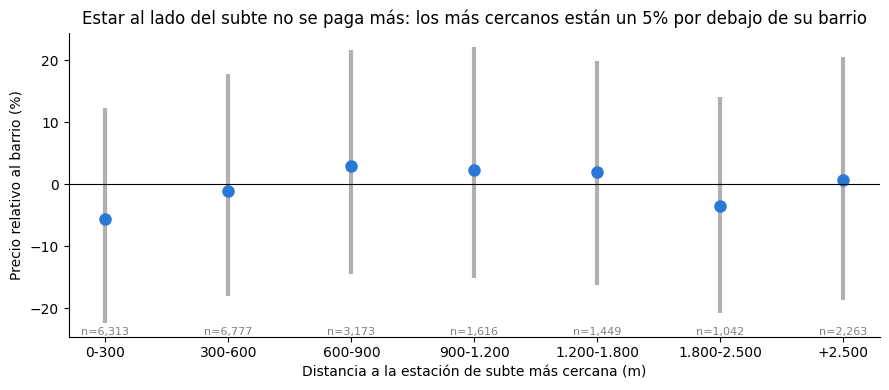

In [16]:
geo["precio_rel_barrio"] = eda.precio_relativo(geo["precio_m2_usd"], geo["barrio"])
tramos = eda.medianas_por_tramo(
    geo["dist_transporte_m"], geo["precio_rel_barrio"],
    cortes=[0, 300, 600, 900, 1200, 1800, 2500, 10000],
    etiquetas=["0-300", "300-600", "600-900", "900-1.200", "1.200-1.800", "1.800-2.500", "+2.500"],
)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(tramos))
ax.vlines(x, 100 * tramos["p25"], 100 * tramos["p75"], color=GRIS, lw=3)
ax.plot(x, 100 * tramos["mediana"], "o", color=AZUL, ms=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(tramos.index)
ax.set_xlabel("Distancia a la estación de subte más cercana (m)")
ax.set_ylabel("Precio relativo al barrio (%)")
ax.set_title("Estar al lado del subte no se paga más: los más cercanos están un 5% por debajo de su barrio")
for xi, n in zip(x, tramos["n"]):
    ax.text(xi, ax.get_ylim()[0], f"n={n:,}", ha="center", va="bottom", fontsize=8, color="gray")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Resultado.** Contra lo esperado, dentro de un mismo barrio los departamentos a menos de 300 m del subte
tienen una mediana un 5,6% **por debajo** de su barrio, y los que están entre 600 y 1.200 m, un 3% por
encima. La correlación dentro del barrio es positiva (a más distancia, algo más caro), aunque débil
(ρ = 0,09). La distancia a los polos de centralidad no tiene relación con el precio dentro del barrio
(ρ ≈ 0).

In [22]:
# Control por antigüedad: se compara dentro del mismo barrio Y el mismo tramo de antigüedad
con_antig = geo[geo["antiguedad"].notna()].copy()
con_antig["tramo_antiguedad"] = pd.cut(con_antig["antiguedad"], [-1, 5, 15, 30, 50, 70, 150])
grupo_control = con_antig["barrio"] + "|" + con_antig["tramo_antiguedad"].astype(str)
cortes = [0, 300, 600, 900, 1200, 1800, 2500, 10000]

comparacion = pd.DataFrame({
    "antigüedad mediana (años)": eda.medianas_por_tramo(con_antig["dist_transporte_m"], con_antig["antiguedad"], cortes)["mediana"],
    "precio relativo al barrio (%)": 100 * eda.medianas_por_tramo(con_antig["dist_transporte_m"], eda.precio_relativo(con_antig["precio_m2_usd"], con_antig["barrio"]), cortes)["mediana"],
    "precio relativo a barrio y antigüedad (%)": 100 * eda.medianas_por_tramo(con_antig["dist_transporte_m"], eda.precio_relativo(con_antig["precio_m2_usd"], grupo_control), cortes)["mediana"],
}).round(1)
comparacion

,antigüedad mediana (años),precio relativo al barrio (%),precio relativo a barrio y antigüedad (%)
dist_transporte_m,,,
"(-0.001, 300.0]",46.0,-5.5,-1.9
"(300.0, 600.0]",41.0,-1.1,0.0
"(600.0, 900.0]",35.0,3.1,1.9
"(900.0, 1200.0]",23.0,2.3,0.7
"(1200.0, 1800.0]",20.0,1.9,-0.1
"(1800.0, 2500.0]",30.0,-3.2,-2.1
"(2500.0, 10000.0]",25.0,0.5,-0.0


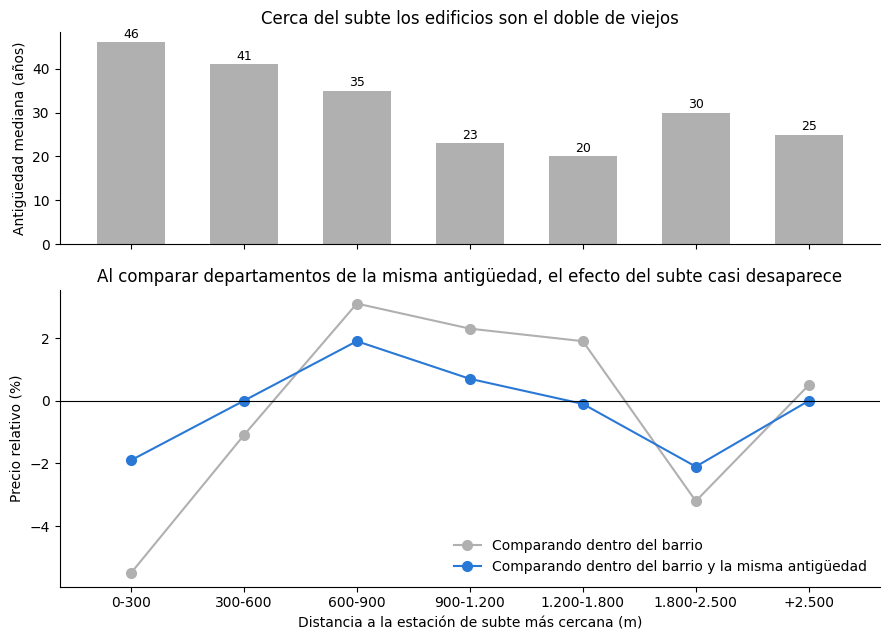

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6.5), sharex=True, gridspec_kw={"height_ratios": [1, 1.4]})
x = np.arange(len(comparacion))
etiquetas = ["0-300", "300-600", "600-900", "900-1.200", "1.200-1.800", "1.800-2.500", "+2.500"]

ax1.bar(x, comparacion["antigüedad mediana (años)"], color=GRIS, width=0.6)
for xi, v in zip(x, comparacion["antigüedad mediana (años)"]):
    ax1.text(xi, v + 1, f"{v:.0f}", ha="center", fontsize=9)
ax1.set_ylabel("Antigüedad mediana (años)")
ax1.set_title("Cerca del subte los edificios son el doble de viejos")

ax2.plot(x, comparacion["precio relativo al barrio (%)"], "o-", color=GRIS, ms=7, label="Comparando dentro del barrio")
ax2.plot(x, comparacion["precio relativo a barrio y antigüedad (%)"], "o-", color=AZUL, ms=7,
         label="Comparando dentro del barrio y la misma antigüedad")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Precio relativo (%)")
ax2.set_title("Al comparar departamentos de la misma antigüedad, el efecto del subte casi desaparece")
ax2.legend(frameon=False, loc="lower right")
ax2.set_xticks(x)
ax2.set_xticklabels(etiquetas)
ax2.set_xlabel("Distancia a la estación de subte más cercana (m)")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

> **Interpretación.** La relación entre el subte y el precio está mezclada con la antigüedad. Los departamentos cerca del subte están en edificios más viejos (antigüedad mediana de 46 años a menos de 300 m, contra 23 años entre 900 y 1.200 m), porque las líneas recorren las zonas de urbanización más antigua. Como la antigüedad es la característica que más pesa sobre el precio (sección 7), el aparente "castigo" por estar cerca del subte es en buena parte un efecto de la antigüedad.
>
> Al comparar departamentos del mismo barrio y del mismo tramo de antigüedad, la diferencia a menos de 300 m baja de −5,6% a −1,9%, y la correlación cae de 0,095 a 0,041. Aun así, la cercanía al subte no muestra una prima de precio, y la distancia a los polos de centralidad no tiene relación con el precio dentro del barrio. **La evidencia no apoya H3:** dentro de un barrio, la ubicación respecto del transporte y del centro no explica diferencias de precio relevantes una vez que se tiene en cuenta la antigüedad. Por eso el modelo del notebook 03 incluye la antigüedad como control principal.

## 7. Características del departamento y precio

**Pregunta:** dentro de una misma sub-zona, ¿qué características se asocian a precios más altos por m²?
Es exploratorio: el modelo del notebook 03 mide el peso de cada una controlando por las demás.

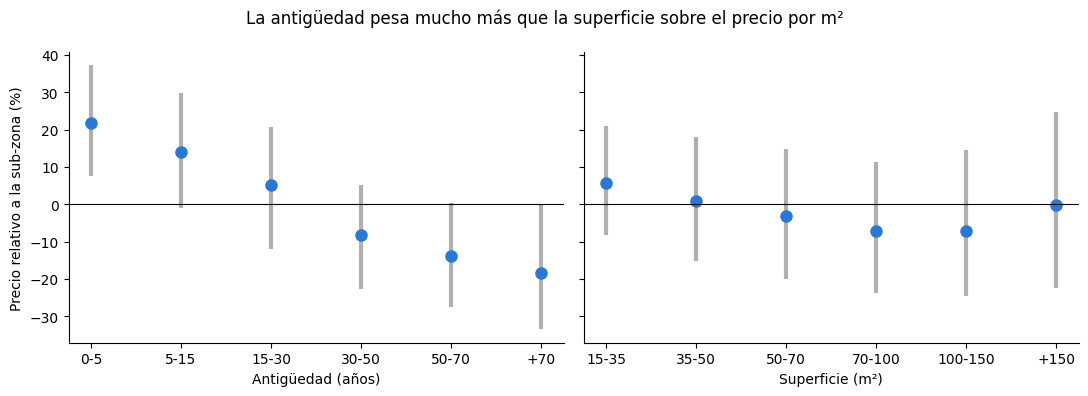

In [17]:
grupo = df["subzona"].fillna(df["barrio"])
df["precio_rel_zona"] = eda.precio_relativo(df["precio_m2_usd"], grupo)

antig = eda.medianas_por_tramo(df["antiguedad"], df["precio_rel_zona"], [-1, 5, 15, 30, 50, 70, 150],
                               ["0-5", "5-15", "15-30", "30-50", "50-70", "+70"])
sup = eda.medianas_por_tramo(df["m2_final"], df["precio_rel_zona"], [15, 35, 50, 70, 100, 150, 1000],
                             ["15-35", "35-50", "50-70", "70-100", "100-150", "+150"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tabla, etiqueta in [(axes[0], antig, "Antigüedad (años)"), (axes[1], sup, "Superficie (m²)")]:
    x = np.arange(len(tabla))
    ax.vlines(x, 100 * tabla["p25"], 100 * tabla["p75"], color=GRIS, lw=3)
    ax.plot(x, 100 * tabla["mediana"], "o", color=AZUL, ms=8)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(tabla.index)
    ax.set_xlabel(etiqueta)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Precio relativo a la sub-zona (%)")
fig.suptitle("La antigüedad pesa mucho más que la superficie sobre el precio por m²")
plt.tight_layout()
plt.show()

In [18]:
caracteristicas = {
    "edificio con amenities (pileta, gimnasio, SUM o parrilla)":
        df[["pileta", "gimnasio", "salon_de_usos_multiples", "parrilla"]].eq("Sí").any(axis=1).astype(int),
    "cochera": (df["cocheras"] > 0).astype(int),
    "balcón": df["balcon"].map({"Sí": 1, "No": 0}),
    "terraza": df["terraza"].map({"Sí": 1, "No": 0}),
    "aire acondicionado": df["aire_acondicionado"].map({"Sí": 1, "No": 0}),
    "apto crédito": df["apto_credito"].map({"Sí": 1, "No": 0}),
    "al frente": df["disposicion"].map(lambda v: np.nan if pd.isna(v) else int(v == "Frente")),
}
filas = []
for nombre, marca in caracteristicas.items():
    dif, n_grupos = eda.diferencia_intra_grupo(df["precio_m2_usd"], marca, grupo)
    filas.append({"característica": nombre, "con la característica (%)": round(100 * marca.mean(), 1),
                  "diferencia de precio/m² en la sub-zona (%)": round(dif, 1), "sub-zonas comparables": n_grupos})
pd.DataFrame(filas).set_index("característica").sort_values("diferencia de precio/m² en la sub-zona (%)", ascending=False)

,con la característica (%),diferencia de precio/m² en la sub-zona (%),sub-zonas comparables
característica,,,
"edificio con amenities (pileta, gimnasio, SUM o parrilla)",24.3,31.0,143
cochera,24.3,21.0,137
balcón,61.9,12.2,179
terraza,17.5,11.4,127
aire acondicionado,42.4,10.5,172
al frente,63.8,1.9,188
apto crédito,48.2,-4.5,186


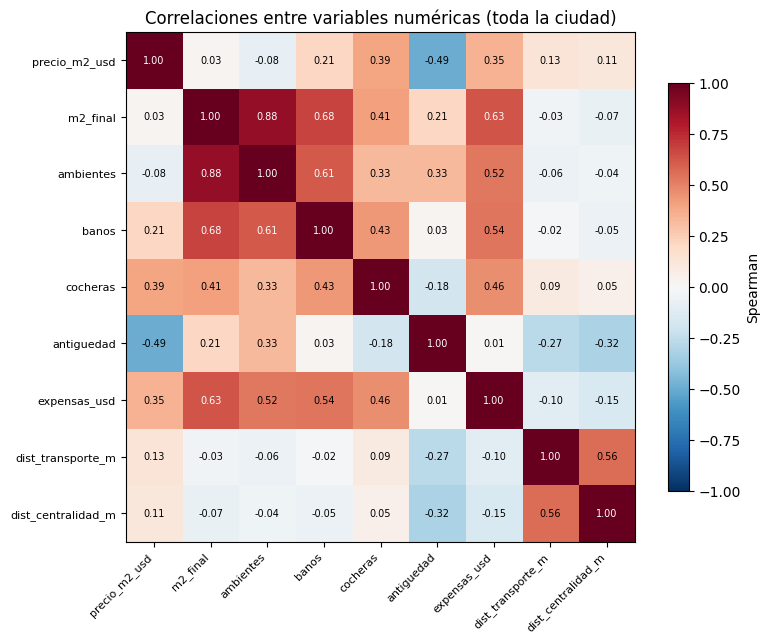

In [19]:
numericas = ["precio_m2_usd", "m2_final", "ambientes", "banos", "cocheras", "antiguedad",
             "expensas_usd", "dist_transporte_m", "dist_centralidad_m"]
correlaciones = df[numericas].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(correlaciones, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(numericas)))
ax.set_xticklabels(numericas, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(numericas)))
ax.set_yticklabels(numericas, fontsize=8)
for i in range(len(numericas)):
    for j in range(len(numericas)):
        ax.text(j, i, f"{correlaciones.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(correlaciones.iloc[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Spearman")
ax.set_title("Correlaciones entre variables numéricas (toda la ciudad)")
plt.tight_layout()
plt.show()

**Resultado.** La antigüedad es la característica con más peso: un departamento de menos de 5 años está
22% por encima de su sub-zona, y uno de más de 70 años, 18% por debajo. La superficie tiene un efecto
menor y en forma de U: los muy chicos tienen el m² más caro. Entre las características, estar en un
edificio con amenities y tener cochera son las que más se asocian a un precio mayor. Las expensas
correlacionan fuerte con la superficie y la cantidad de ambientes, como es de esperar.

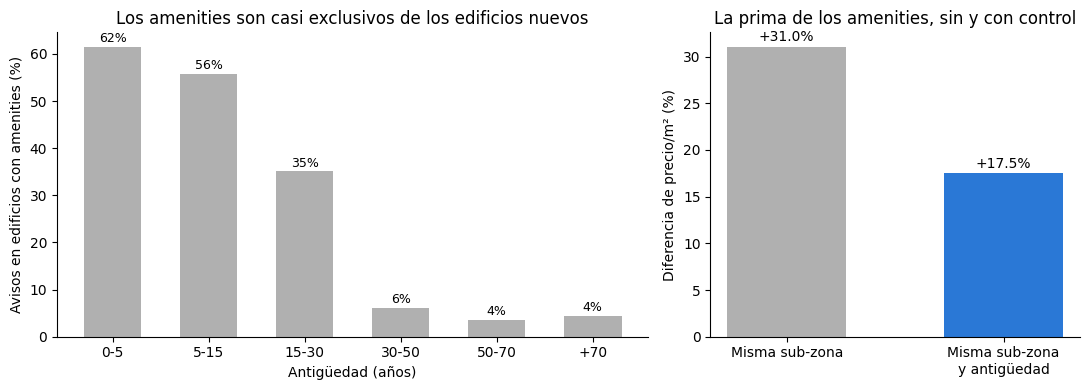

In [24]:
# ¿Los amenities van de la mano con la antigüedad?
con_amen = df[df["antiguedad"].notna()].copy()
con_amen["amenities"] = con_amen[["pileta", "gimnasio", "salon_de_usos_multiples", "parrilla"]].eq("Sí").any(axis=1).astype(int)
con_amen["tramo_antiguedad"] = pd.cut(con_amen["antiguedad"], [-1, 5, 15, 30, 50, 70, 150],
                                      labels=["0-5", "5-15", "15-30", "30-50", "50-70", "+70"])
pct_amenities = 100 * con_amen.groupby("tramo_antiguedad", observed=True)["amenities"].mean()

zona = con_amen["subzona"].fillna(con_amen["barrio"])
prima_simple, _ = eda.diferencia_intra_grupo(con_amen["precio_m2_usd"], con_amen["amenities"], zona)
prima_control, _ = eda.diferencia_intra_grupo(con_amen["precio_m2_usd"], con_amen["amenities"],
                                              zona + "|" + con_amen["tramo_antiguedad"].astype(str))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [1.6, 1]})
ax1.bar(pct_amenities.index.astype(str), pct_amenities, color=GRIS, width=0.6)
for i, v in enumerate(pct_amenities):
    ax1.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=9)
ax1.set_xlabel("Antigüedad (años)")
ax1.set_ylabel("Avisos en edificios con amenities (%)")
ax1.set_title("Los amenities son casi exclusivos de los edificios nuevos")

ax2.bar(["Misma sub-zona", "Misma sub-zona\ny antigüedad"], [prima_simple, prima_control], color=[GRIS, AZUL], width=0.55)
for i, v in enumerate([prima_simple, prima_control]):
    ax2.text(i, v + 0.6, f"+{v:.1f}%", ha="center", fontsize=10)
ax2.set_ylabel("Diferencia de precio/m² (%)")
ax2.set_title("La prima de los amenities, sin y con control")
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

> **Interpretación.** La diferencia de +31% para los edificios con amenities no se puede leer directamente como el efecto de los amenities, porque mezcla otra variable: la antigüedad. Los amenities son casi exclusivos de los edificios nuevos (los tiene el 62% de los departamentos de hasta 5 años, contra 4 a 6% de los de más de 30), y la antigüedad es la característica que más pesa sobre el precio. Al comparar departamentos de la misma sub-zona y del mismo tramo de antigüedad, la prima de los amenities baja a +17,5%: sigue siendo importante, pero es casi la mitad de lo que parecía.
>
> Es el mismo problema que con el subte (sección 6): una asociación simple puede estar reflejando otra variable que va de la mano. Por eso el modelo de precio esperado del notebook 03 estima el peso de cada característica controlando por las demás, en lugar de usar estas diferencias simples.

## 8. Los avisos marcados en la limpieza

**Pregunta:** ¿los grupos que se marcaron en el notebook 01 se comportan distinto en precio?

In [20]:
marcas = ["bajo_de_precio", "posible_duplicado", "menciona_alquiler", "outlier_precio_m2"]
filas = []
for m in marcas:
    filas.append({
        "marca": m,
        "avisos": int(df[m].sum()),
        "% del total": round(100 * df[m].mean(), 1),
        "precio relativo mediano con la marca (%)": round(100 * df.loc[df[m], "precio_rel_zona"].median(), 1),
        "precio relativo mediano sin la marca (%)": round(100 * df.loc[~df[m], "precio_rel_zona"].median(), 1),
    })
pd.DataFrame(filas).set_index("marca")

,avisos,% del total,precio relativo mediano con la marca (%),precio relativo mediano sin la marca (%)
marca,,,,
bajo_de_precio,626,2.3,-10.6,-1.0
posible_duplicado,3059,11.1,-0.6,-1.4
menciona_alquiler,162,0.6,11.1,-1.3
outlier_precio_m2,928,3.4,63.4,-2.2


In [21]:
# ¿Los posibles duplicados cambian la foto por barrio? Medianas con y sin ellos
con = df.groupby("barrio")["precio_m2_usd"].median()
sin = df[~df["posible_duplicado"]].groupby("barrio")["precio_m2_usd"].median()
cambio = 100 * (sin / con - 1)
print(f"Cambio en la mediana por barrio al sacar posibles duplicados: máximo {cambio.abs().max():.1f}%, mediano {cambio.abs().median():.1f}%")

Cambio en la mediana por barrio al sacar posibles duplicados: máximo 5.6%, mediano 0.7%


**Resultado.** Los avisos que bajaron de precio están 11% por debajo de su sub-zona: son los únicos con
indicio de urgencia de venta, y se los distingue en el análisis del notebook 03. Los posibles duplicados
casi no cambian las medianas por barrio, así que se pueden conservar sin distorsionar la foto. Los
atípicos de precio por m² son casi todos caros para su zona.

## 9. Síntesis del EDA

### Evidencia preliminar sobre las hipótesis

| Hipótesis | Evidencia preliminar | Estado |
|---|---|---|
| H1: hay avisos claramente por debajo del precio esperado | Requiere el modelo de precio esperado | Se evalúa en el notebook 03 |
| H2: la sub-zona da una referencia más precisa que el barrio | Mejora mucho en algunos barrios (Villa Lugano: de 25% a 14% de error) y casi nada o empeora en otros. En el total, de 17,7% a 17,2% | Apoyo parcial: depende del barrio |
| H3: la ubicación explica diferencias dentro del barrio | La cercanía al subte se asocia a precios algo **menores**, y la centralidad no tiene relación | No se apoya en la forma planteada |

### Hipótesis o preguntas que todavía no se pueden evaluar

- **Evolución en el tiempo** (si el gap de un aviso se sostiene o se cierra): hay una sola foto, sin fechas de
  publicación. Requiere repetir el scraping.
- **Liquidez y tiempo de venta:** no hay fecha de publicación ni de baja del aviso.
- **Precio de cierre:** solo hay precio publicado; la brecha se toma de fuentes externas (~5%).
- **Rentabilidad por alquiler:** no hay datos de alquiler.

### Próximos pasos (notebook 03)

1. Construir el precio esperado de cada aviso según sus características y su sub-zona, con validación fuera de muestra.
2. Incluir la antigüedad como control principal, dado su peso en esta exploración.
3. Medir el gap de cada aviso y elegir, mirando su distribución, el umbral de "atípicamente barato" por encima del 5% de negociación.
4. Revisar la lista de avisos marcados con `bajo_de_precio` aparte, porque pueden ser vendedores apurados y no oportunidades.